In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

In [5]:
df=pd.read_csv("C:/Project_Folder_ML26/Notebook/data/processed/olist_orders_abt.csv")
df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,...,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,...,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,...,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,...,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,...,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,...,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [6]:
df.shape

(99441, 29)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int64  
 7   order_month               99441 non-null  int64  
 8   order_day                 99441 non-null  int64  
 9   order_day_of_week         99441 non-null  int64  
 10  order_hour                99441 non-null  int64  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  int64  
 13  delivery_delay_days       96476 non-null  float64
 14  is_late_delivery 

In [8]:
df.describe()

,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,...,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,total_items,total_price,total_freight,unique_products,unique_sellers
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,96476.000000,99441.000000,96476.000000,99441.000000,98673.000000,...,98673.000000,98673.000000,99440.000000,99440.000000,99440.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000
mean,2017.539838,6.032220,15.505948,2.755735,14.770829,12.094086,23.403958,-11.876881,0.065717,4.086793,...,0.415281,0.413852,160.990267,2.930521,1.022586,1.141731,137.754076,22.823562,1.038098,1.013622
std,0.505007,3.232999,8.667298,1.966495,5.326800,9.551746,8.829562,10.183854,0.247789,1.346274,...,0.495685,0.492525,221.951257,2.715685,0.148582,0.538452,210.645145,21.650909,0.226456,0.122297
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,-147.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.850000,0.000000,1.000000,1.000000
25%,2017.000000,3.000000,8.000000,1.000000,11.000000,6.000000,18.000000,-17.000000,0.000000,4.000000,...,0.000000,0.000000,62.010000,1.000000,1.000000,1.000000,45.900000,13.850000,1.000000,1.000000
50%,2018.000000,6.000000,15.000000,3.000000,15.000000,10.000000,23.000000,-12.000000,0.000000,5.000000,...,0.000000,0.000000,105.290000,2.000000,1.000000,1.000000,86.900000,17.170000,1.000000,1.000000
75%,2018.000000,8.000000,23.000000,4.000000,19.000000,15.000000,28.000000,-7.000000,0.000000,5.000000,...,1.000000,1.000000,176.970000,4.000000,1.000000,1.000000,149.900000,24.040000,1.000000,1.000000
max,2018.000000,12.000000,31.000000,6.000000,23.000000,209.000000,155.000000,188.000000,1.000000,5.000000,...,3.000000,1.000000,13664.080000,24.000000,2.000000,21.000000,13440.000000,1794.960000,8.000000,5.000000


In [9]:
nominal_columns=[
    "customer_state",
    "customer_city",
    "main_product_category",
    "dominant_payment_type",
    "order_status"
]

ordinal_columns=[
    "review_score"
]

In [10]:
interval_columns=[
    "order_hour",
    "order_month",
    "order_day_of_week"
]

ratio_columns=[
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivary_days",
    "estimated_delay_days",
    "total_items",
    "unique_products",
    "unique_sellers"
]

In [11]:
df.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_status', 'order_year', 'order_month',
       'order_day', 'order_day_of_week', 'order_hour', 'delivery_days',
       'estimated_delivery_days', 'delivery_delay_days', 'is_late_delivery',
       'review_score', 'is_low_review', 'review_comment_count',
       'has_review_comment', 'total_payment_value', 'max_payment_installments',
       'payment_types_count', 'dominant_payment_type', 'total_items',
       'total_price', 'total_freight', 'unique_products', 'unique_sellers',
       'main_product_category'],
      dtype='str')

In [12]:
def keep_existing_columns(dataframe, columns):
    return [col for col in columns if col in dataframe.columns]
nominal_columns = keep_existing_columns(df, nominal_columns)
ordinal_columns = keep_existing_columns(df, ordinal_columns)
interval_columns = keep_existing_columns(df, interval_columns)
ratio_columns = keep_existing_columns(df, ratio_columns)

In [13]:
#Creating Delivary Speed Category

In [14]:
if "delivery_days" in df.columns:
    df["delivery_speed_category"]=pd.cut(
        df["delivery_days"],
        bins=[-1,7,15,30,np.inf],
        labels=["Fast","Normal","Slow","Very Delayed"]
    )

In [15]:
#Creating Payment Value Band

In [16]:
if "total_payment_value" in df.columns: 
    df["payment_value_band"] = pd.qcut( 
        df["total_payment_value"], 
        q=4, 
        labels=["Low", "Medium", "High", "Premium"], 
        duplicates="drop" 
    )

In [17]:
#Finding Missing Values

In [18]:
df.isnull().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_status                   0
order_year                     0
order_month                    0
order_day                      0
order_day_of_week              0
order_hour                     0
delivery_days               2965
estimated_delivery_days        0
delivery_delay_days         2965
is_late_delivery               0
review_score                 768
is_low_review                  0
review_comment_count         768
has_review_comment           768
total_payment_value            1
max_payment_installments       1
payment_types_count            1
dominant_payment_type          1
total_items                  775
total_price                  775
total_freight                775
unique_products              775
unique_sellers               775
main_product_category       2185
delivery_speed_category     2965
payment_va

In [19]:
missing_summary = pd.DataFrame({ 
    "missing_count": df.isnull().sum(), 
    "missing_percent": (df.isnull().sum() / len(df)) * 100 
}).sort_values(by="missing_percent", ascending=False) 
missing_summary.head(20)

,missing_count,missing_percent
delivery_delay_days,2965,2.981668
delivery_days,2965,2.981668
delivery_speed_category,2965,2.981668
main_product_category,2185,2.197283
total_price,775,0.779357
unique_sellers,775,0.779357
total_freight,775,0.779357
total_items,775,0.779357
unique_products,775,0.779357
review_score,768,0.772317


In [20]:
#Missing Value Bar Plot

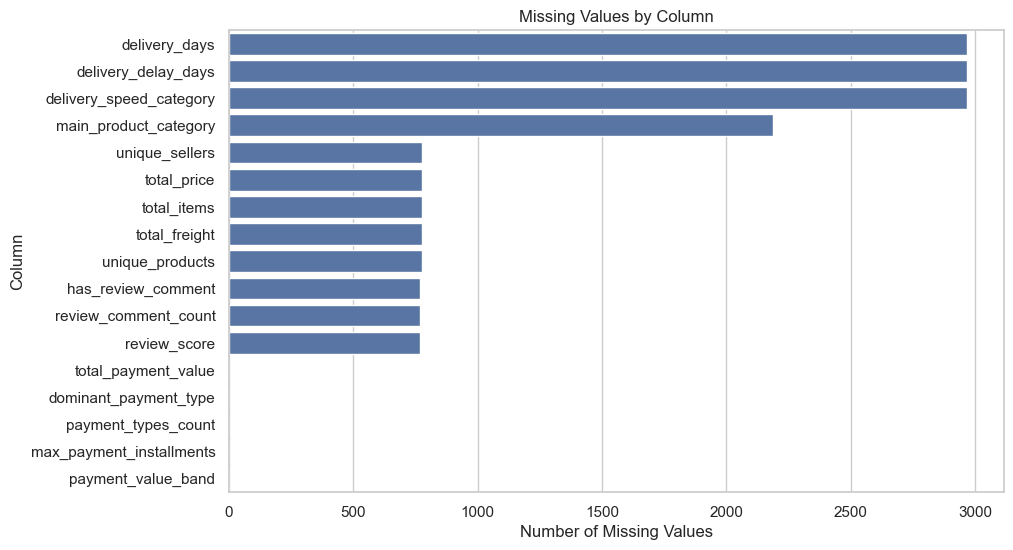

In [21]:
missing_values = df.isnull().sum() 
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
sns.barplot( x=missing_values.values, y=missing_values.index )
plt.title("Missing Values by Column") 
plt.xlabel("Number of Missing Values") 
plt.ylabel("Column") 
plt.show()

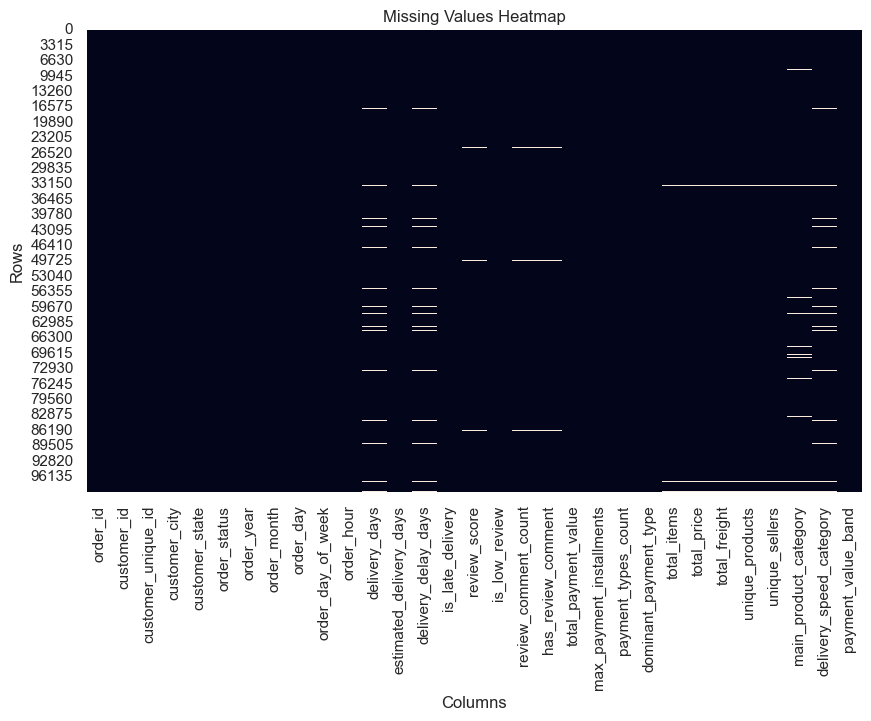

In [22]:
#Heatmap
sns.heatmap( 
    df.isnull(), 
    cbar=False ) 
plt.title("Missing Values Heatmap") 
plt.xlabel("Columns") 
plt.ylabel("Rows") 
plt.show()

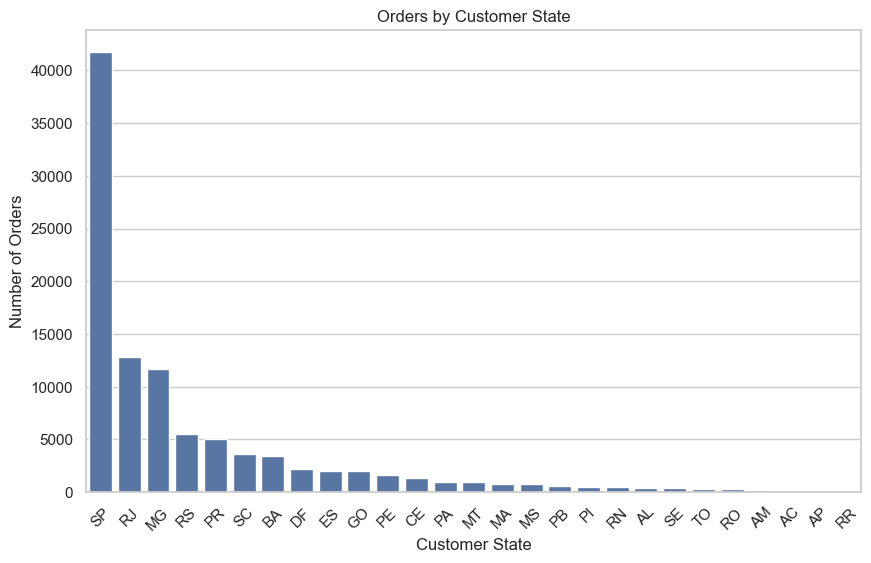

In [23]:
#Univariate Analysis
#Count Plot for Nominal Data(Customer State)
if "customer_state" in df.columns: 
    sns.countplot( 
        data=df, 
        x="customer_state", 
        order=df["customer_state"].value_counts().index 
    )
plt.title("Orders by Customer State") 
plt.xlabel("Customer State") 
plt.ylabel("Number of Orders") 
plt.xticks(rotation=45) 
plt.show()

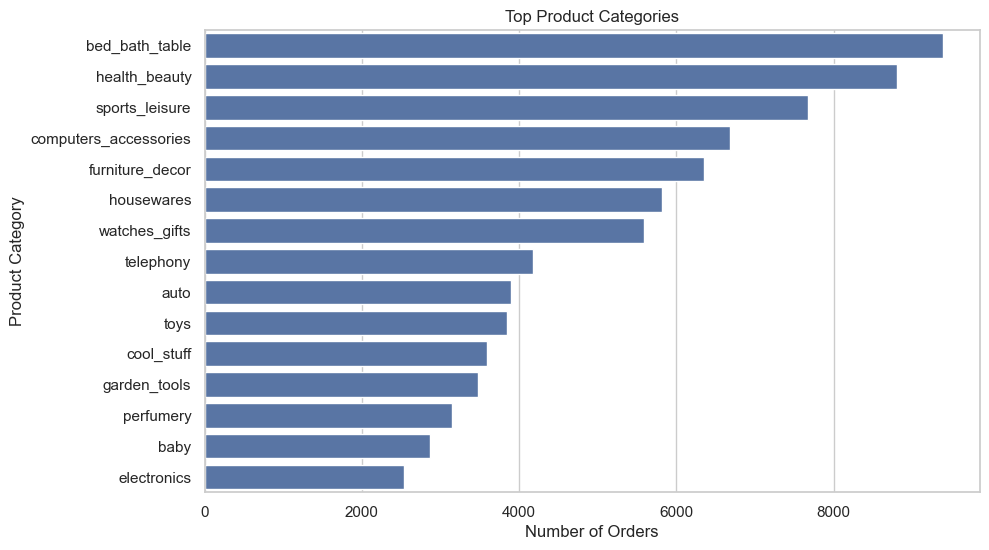

In [24]:
#Count Plot for Product Category
if "main_product_category" in df.columns: 
    top_categories = df["main_product_category"].value_counts().head(15).index
sns.countplot( 
    data=df[df["main_product_category"].isin(top_categories)], 
    y="main_product_category", 
    order=top_categories )
plt.title("Top Product Categories") 
plt.xlabel("Number of Orders") 
plt.ylabel("Product Category")
plt.show()

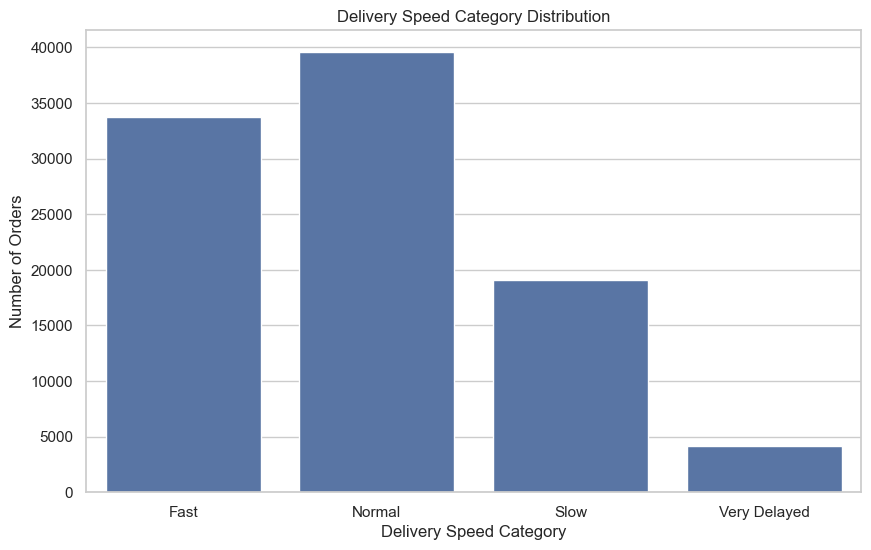

In [25]:
#Count Plot for Ordinal Data
if "delivery_speed_category" in df.columns: 
    delivery_order = ["Fast", "Normal", "Slow", "Very Delayed"]
sns.countplot(
    data=df,
    x="delivery_speed_category", 
    order=delivery_order 
)
plt.title("Delivery Speed Category Distribution") 
plt.xlabel("Delivery Speed Category") 
plt.ylabel("Number of Orders")
plt.show()

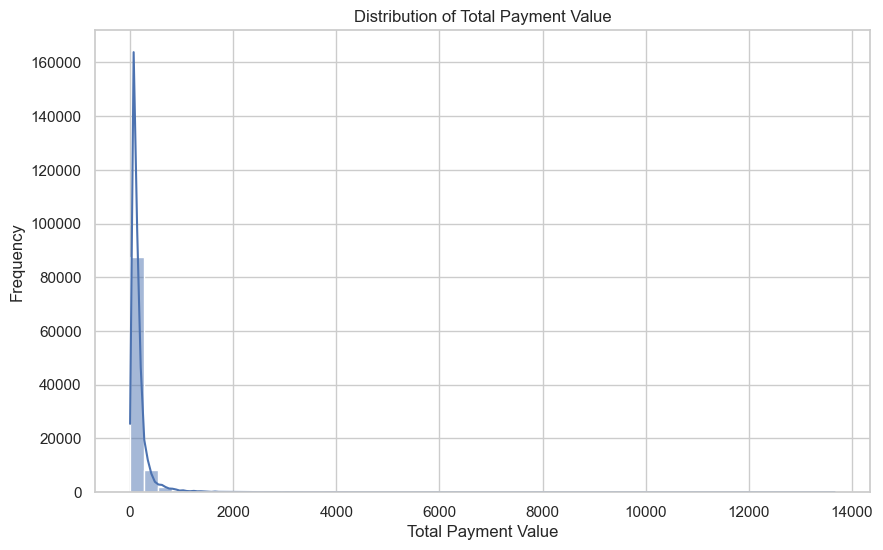

In [26]:
#Histogram for Numerical Data
#Total Payment Value
if "total_payment_value" in df.columns: 
    sns.histplot( 
        data=df, x="total_payment_value", bins=50, kde=True 
    ) 
    plt.title("Distribution of Total Payment Value") 
    plt.xlabel("Total Payment Value") 
    plt.ylabel("Frequency") 
    plt.show()

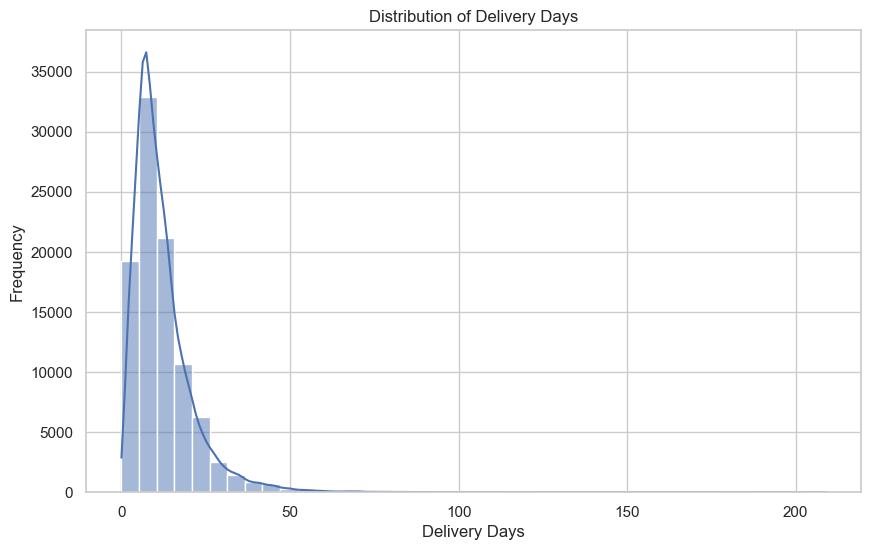

In [27]:
#Histogram for Delivery Days
if "delivery_days" in df.columns: 
    sns.histplot( data=df, x="delivery_days", bins=40, kde=True ) 
    plt.title("Distribution of Delivery Days") 
    plt.xlabel("Delivery Days") 
    plt.ylabel("Frequency") 
    plt.show()

In [28]:
#Skewness
skew_cols = [ 
    "total_payment_value", 
    "total_price", 
    "total_freight", 
    "delivery_days", 
    "delivery_delay_days", 
    "total_items" 
]
skew_cols = keep_existing_columns(df, skew_cols) 
skewness_values = df[skew_cols].skew().sort_values(ascending=False) 
skewness_values

total_freight          12.052723
total_price             9.727741
total_payment_value     9.150169
total_items             7.527006
delivery_days           3.828790
delivery_delay_days     2.014360
dtype: float64

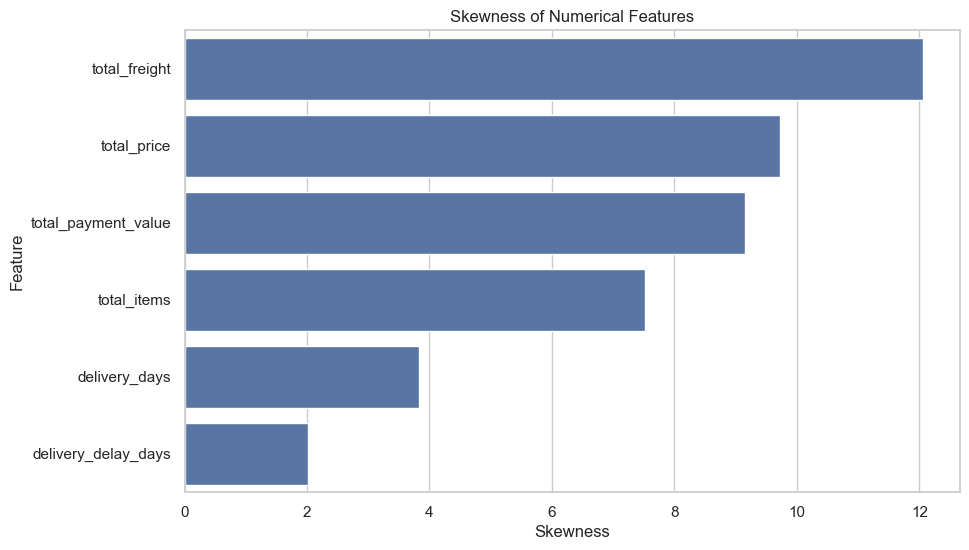

In [29]:
sns.barplot( x=skewness_values.values, y=skewness_values.index ) 
plt.title("Skewness of Numerical Features") 
plt.xlabel("Skewness") 
plt.ylabel("Feature") 
plt.show()

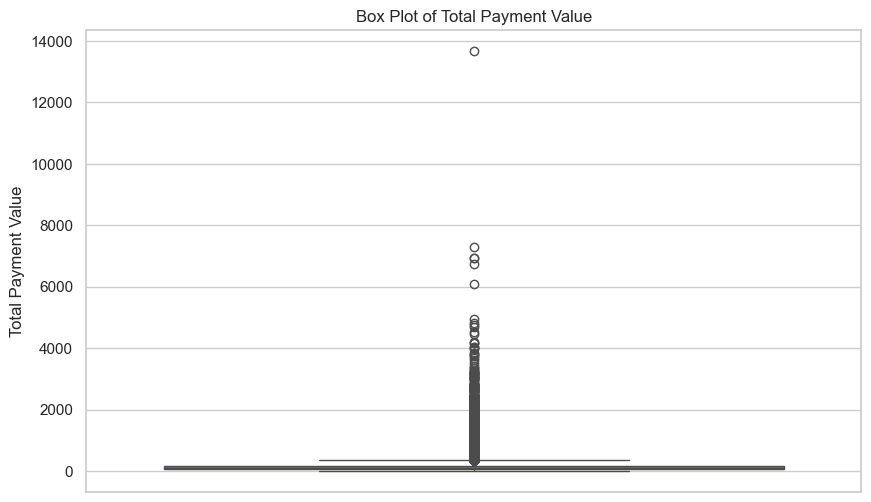

In [30]:
#Box Plot for Payment Value
if "total_payment_value" in df.columns: 
    sns.boxplot( data=df, y="total_payment_value" ) 
    plt.title("Box Plot of Total Payment Value") 
    plt.ylabel("Total Payment Value") 
    plt.show()

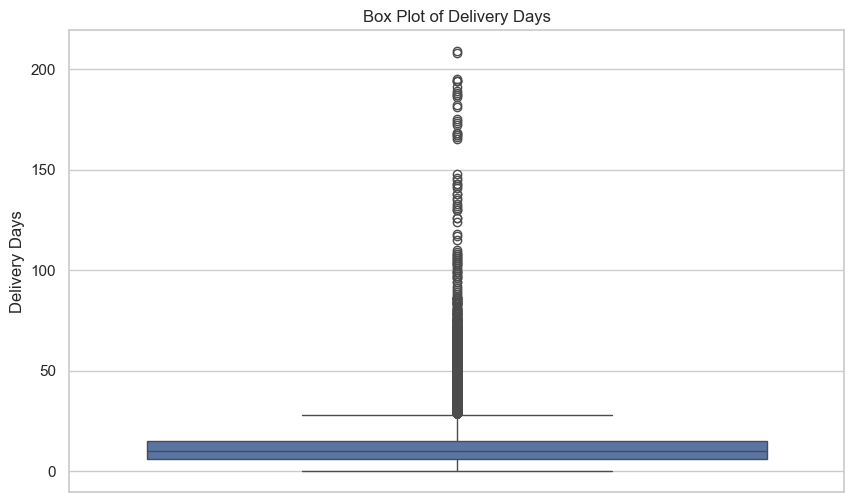

In [31]:
#Box Plot for Delivery Days
if "delivery_days" in df.columns: 
    sns.boxplot( data=df, y="delivery_days" ) 
    plt.title("Box Plot of Delivery Days") 
    plt.ylabel("Delivery Days") 
    plt.show()

In [32]:
#IQR Method for Outlier Detection
def iqr_outlier_summary(dataframe, column): 
    q1 = dataframe[column].quantile(0.25) 
    q3 = dataframe[column].quantile(0.75) 
    iqr = q3 - q1 
    lower_bound = q1 - 1.5 * iqr 
    upper_bound = q3 + 1.5 * iqr 
    outliers = dataframe[ 
        (dataframe[column] < lower_bound) | (dataframe[column] > upper_bound) 
        ] 
    summary = { 
        "column": column, 
        "q1": q1, 
        "q3": q3, 
        "iqr": iqr, 
        "lower_bound": lower_bound, 
        "upper_bound": upper_bound, 
        "outlier_count": len(outliers), 
        "outlier_percent": (len(outliers) / len(dataframe)) * 100 
    } 
    return summary
if "total_payment_value" in df.columns: 
    iqr_outlier_summary(df, "total_payment_value")
if "total_payment_value" in df.columns: 
    iqr_outlier_summary(df, "total_payment_value")

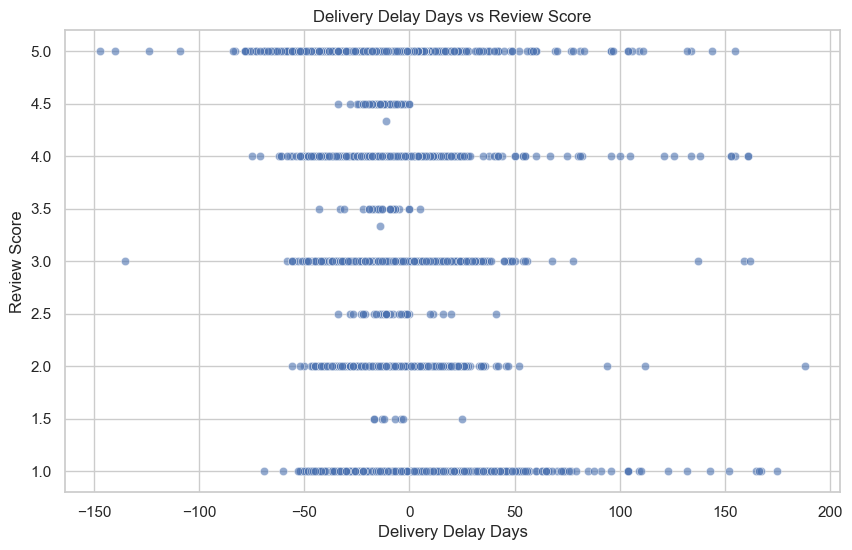

In [33]:
#Multivariate Analysis
#Part H: Multivariate Analysis
if {"delivery_delay_days", "review_score"}.issubset(df.columns): 
    sns.scatterplot( 
        data=df, 
        x="delivery_delay_days", 
        y="review_score", 
        alpha=0.6 
    ) 
    plt.title("Delivery Delay Days vs Review Score") 
    plt.xlabel("Delivery Delay Days") 
    plt.ylabel("Review Score") 
    plt.show()

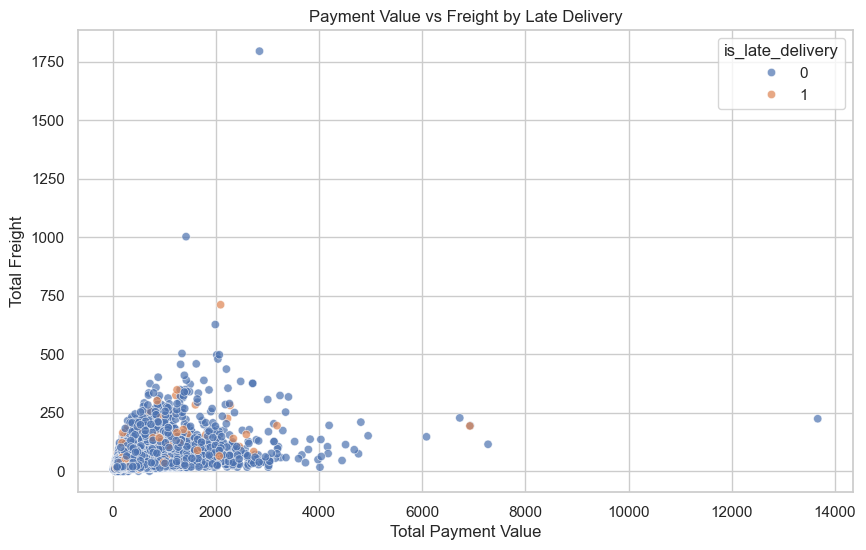

In [34]:
#Scatter Plot with Target Color
if {"total_payment_value", "total_freight", "is_late_delivery"}.issubset(df.columns):
    sns.scatterplot( data=df, x="total_payment_value", y="total_freight", hue="is_late_delivery", alpha=0.7 ) 
    plt.title("Payment Value vs Freight by Late Delivery") 
    plt.xlabel("Total Payment Value") 
    plt.ylabel("Total Freight") 
    plt.show()

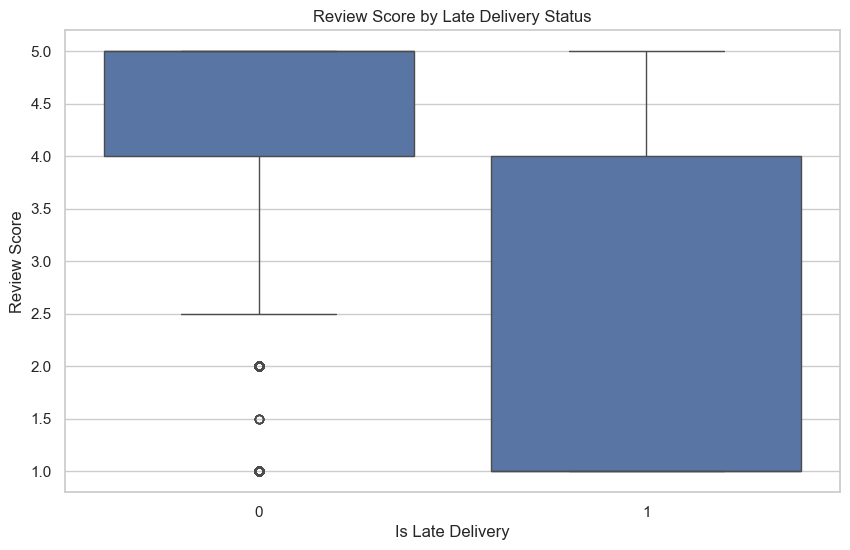

In [35]:
#Box Plot by Target
if {"is_late_delivery", "review_score"}.issubset(df.columns): 
    sns.boxplot( 
        data=df, 
        x="is_late_delivery", 
        y="review_score" 
    )
    plt.title("Review Score by Late Delivery Status") 
    plt.xlabel("Is Late Delivery") 
    plt.ylabel("Review Score") 
    plt.show()

In [37]:
#Correlation Heatmap
numeric_columns = [ 
    "order_hour", 
    "order_month", 
    "order_day_of_week", 
    "total_payment_value", 
    "total_price", 
    "total_freight",
    "delivery_days", 
    "estimated_delivery_days", 
    "delivery_delay_days", 
    "total_items", 
    "unique_products", 
    "unique_sellers", 
    "review_score", 
    "has_review_comment", 
    "review_comment_count", 
    "is_late_delivery", 
    "is_low_review" 
] 

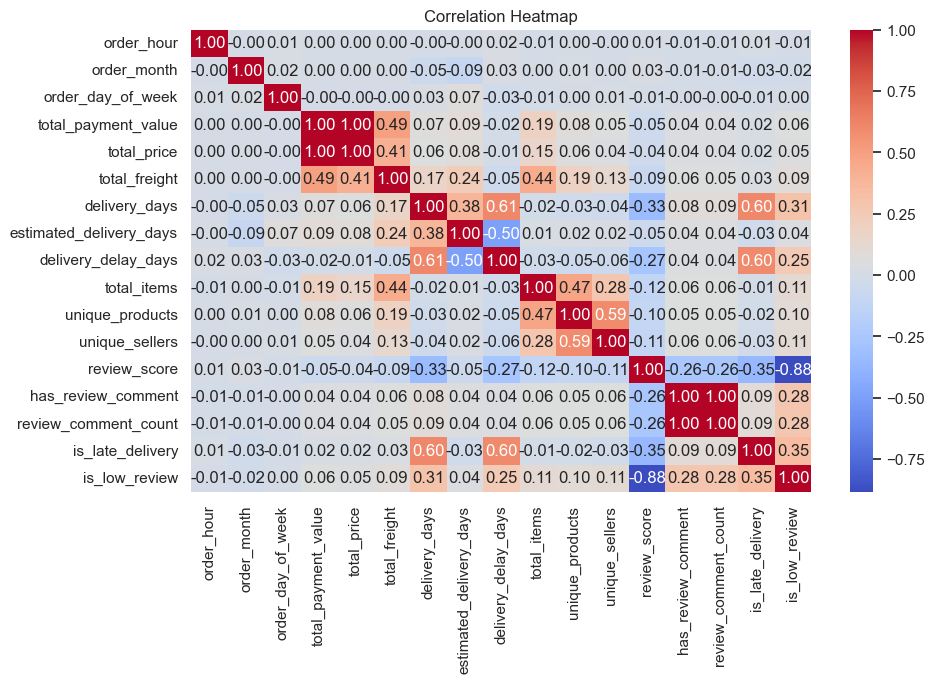

In [39]:
numeric_columns = keep_existing_columns(df, numeric_columns) 
corr = df[numeric_columns].corr() 
sns.heatmap( corr, annot=True, cmap="coolwarm", fmt=".2f" ) 
plt.title("Correlation Heatmap") 
plt.show()

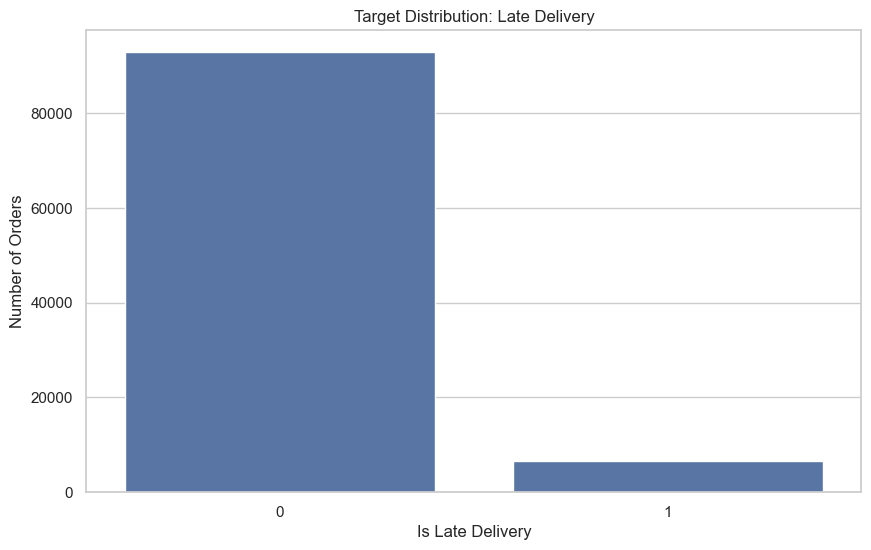

In [40]:
#Target Variable Analysis
if "is_late_delivery" in df.columns: 
    sns.countplot( data=df, x="is_late_delivery" ) 
    plt.title("Target Distribution: Late Delivery") 
    plt.xlabel("Is Late Delivery") 
    plt.ylabel("Number of Orders") 
    plt.show()

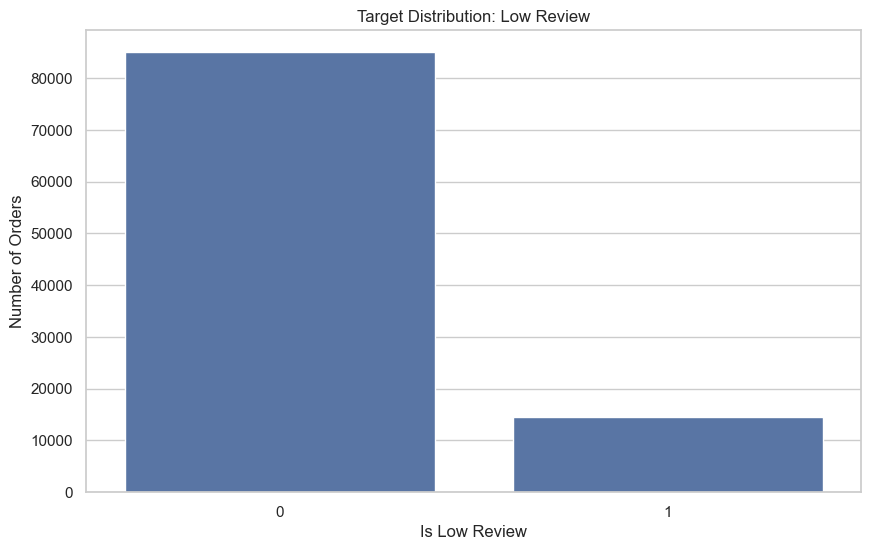

In [41]:
#Target Distribution: Low Review
if "is_low_review" in df.columns: 
    sns.countplot( data=df, x="is_low_review" ) 
    plt.title("Target Distribution: Low Review") 
    plt.xlabel("Is Low Review") 
    plt.ylabel("Number of Orders") 
    plt.show()

In [42]:
#Fixing Data Problems
#Creating copy for cleaning
clean_df = df.copy()

In [43]:
#Adding Missingness Indicator for Delivery Days
if "delivery_days" in clean_df.columns: 
    clean_df["missing_delivery_days"] = clean_df["delivery_days"].isnull().astype(int)

In [46]:
#Handling Missing Categorical Values
categorical_missing_cols = [ 
    "main_product_category", 
    "dominant_payment_type", 
    "delivery_speed_category", 
    "payment_value_band", 
    "customer_state", 
    "customer_city", 
    "order_status" 
]

In [48]:
categorical_missing_cols = keep_existing_columns(clean_df, categorical_missing_cols)
for col in categorical_missing_cols:
    clean_df[col] = clean_df[col].astype("object").fillna("Unknown")

In [49]:
#Handling Missing Numerical Values
numerical_missing_cols = [ 
    "total_payment_value", 
    "total_price", 
    "total_freight", 
    "delivery_days", 
    "estimated_delivery_days", 
    "delivery_delay_days", 
    "review_score", 
    "total_items", 
    "unique_products", 
    "unique_sellers" 
]

numerical_missing_cols = keep_existing_columns(clean_df, numerical_missing_cols)
for col in numerical_missing_cols: 
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

In [50]:
#Log Transformation for Skewed Data
if "total_payment_value" in clean_df.columns: 
    clean_df["log_total_payment_value"] = np.log1p(clean_df["total_payment_value"])
if "total_freight" in clean_df.columns: 
    clean_df["log_total_freight"] = np.log1p(clean_df["total_freight"])
if "total_price" in clean_df.columns: 
    clean_df["log_total_price"] = np.log1p(clean_df["total_price"])

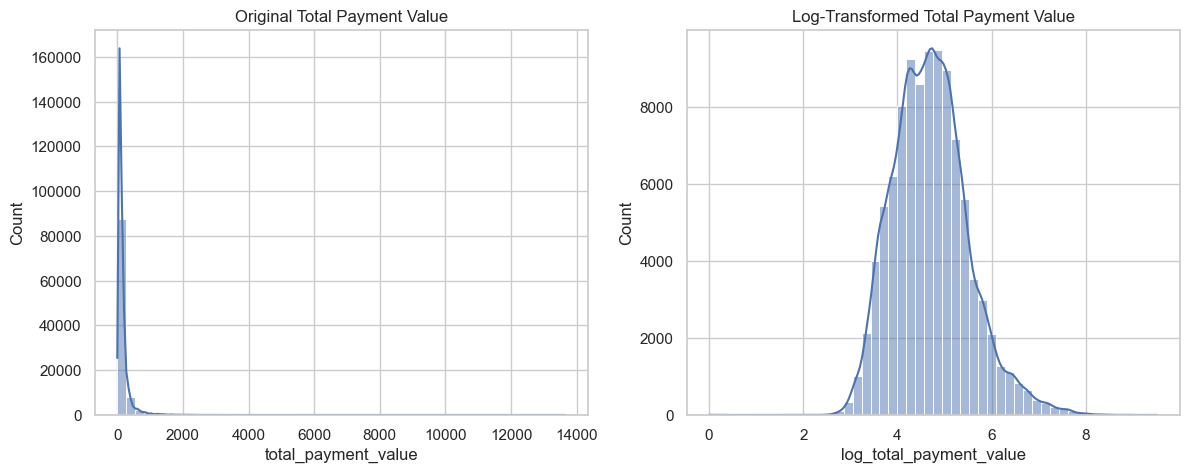

In [51]:
#Comparing Original and Log-Transformed Distribution
if {"total_payment_value", "log_total_payment_value"}.issubset(clean_df.columns): 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
    sns.histplot( 
        data=clean_df, 
        x="total_payment_value", 
        bins=50, 
        kde=True, 
        ax=axes[0] 
    ) 
    axes[0].set_title("Original Total Payment Value") 
    sns.histplot( 
        data=clean_df, 
        x="log_total_payment_value", 
        bins=50, 
        kde=True, 
        ax=axes[1] 
    ) 
    axes[1].set_title("Log-Transformed Total Payment Value") 
    plt.show()

In [52]:
#Scaling Demonstration
scale_check_cols = [ 
    "total_payment_value", 
    "total_price", 
    "total_freight", 
    "delivery_days", 
    "total_items" 
] 
scale_check_cols = keep_existing_columns(clean_df, scale_check_cols) 
clean_df[scale_check_cols].describe()

,total_payment_value,total_price,total_freight,delivery_days,total_items
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000
mean,160.989707,137.357742,22.779500,12.031647,1.140626
std,221.950211,209.870343,21.572104,9.415006,0.536495
min,0.000000,0.850000,0.000000,0.000000,1.000000
25%,62.010000,45.990000,13.900000,6.000000,1.000000
50%,105.290000,86.900000,17.170000,10.000000,1.000000
75%,176.970000,149.900000,23.920000,15.000000,1.000000
max,13664.080000,13440.000000,1794.960000,209.000000,21.000000


In [53]:
#Applying  StandardScaler, MinMaxScaler, and RobustScaler
scaling_cols = [ 
    "total_payment_value", 
    "total_price", 
    "total_freight", 
    "delivery_days", 
    "total_items" 
]
scaling_cols = keep_existing_columns(clean_df, scaling_cols)

standard_scaler = StandardScaler() 
minmax_scaler = MinMaxScaler() 
robust_scaler = RobustScaler()

standard_scaled = standard_scaler.fit_transform(clean_df[scaling_cols]) 
minmax_scaled = minmax_scaler.fit_transform(clean_df[scaling_cols]) 
robust_scaled = robust_scaler.fit_transform(clean_df[scaling_cols])

standard_scaled_df = pd.DataFrame( 
    standard_scaled, 
    columns=[col + "_standard_scaled" for col in scaling_cols] )

minmax_scaled_df = pd.DataFrame( 
    minmax_scaled, 
    columns=[col + "_minmax_scaled" for col in scaling_cols] )
robust_scaled_df = pd.DataFrame( 
    robust_scaled, 
    columns=[col + "_robust_scaled" for col in scaling_cols] )

standard_scaled_df.head()

,total_payment_value_standard_scaled,total_price_standard_scaled,total_freight_standard_scaled,delivery_days_standard_scaled,total_items_standard_scaled
0,-0.550936,-0.511593,-0.651748,-0.428217,-0.262121
1,-0.087992,-0.088902,-0.000904,0.102853,-0.262121
2,0.081687,0.107411,-0.165006,-0.322003,-0.262121
3,-0.400045,-0.440073,0.204918,0.102853,-0.262121
4,-0.596397,-0.559671,-0.651748,-1.065501,-0.262121


In [54]:
#Saving Cleaned ABT
clean_df.to_csv("C:/Project_Folder_ML26/Notebook/data/processed/olist_orders_abt_cleaned.csv", index=False)
print("Cleaned ABT saved successfully.") 
print(clean_df.shape)

Cleaned ABT saved successfully.
(99441, 35)
